# ADReSS Handcrafted-Feature Error Analysis

This notebook provides a structured error analysis of the L1-regularised logistic regression model trained on handcrafted linguistic features for the ADReSS dataset. It goes beyond confusion-matrix counts to investigate **why** the model fails on specific participants.

Analysis is **ADReSS-only** because CCC does not contain gender information.

The notebook:
- Re-runs the identical CV pipeline (same seed, same pruning, same hyperparameters) to collect per-subject predictions
- Does **not** retrain any new model or change any experimental setup
- Uses the saved outputs wherever possible for cross-domain interpretation

**Sections**
1. Per-Subject Misclassification Analysis
2. Gender-Based Error Analysis
3. Feature-Based Error Pattern Analysis
4. Transcript-Length / Complexity Analysis
5. Qualitative Case Analysis
6. Confusion Matrix Interpretation
7. Cross-Domain Error Interpretation
8. Publication-Quality Visualisations

In [1]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, StratifiedGroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix
)

# ── Thesis plot style ──────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', font_scale=1.1)
PALETTE = {'FP': '#E53935', 'FN': '#1E88E5', 'TP': '#43A047', 'TN': '#8E24AA',
           'correct': '#43A047', 'error': '#E53935',
           'male': '#1E88E5', 'female': '#E91E63'}
plt.rcParams.update({'figure.dpi': 150, 'savefig.bbox': 'tight'})

In [2]:
# ── Paths ──────────────────────────────────────────────────────────────────
BASE_DIR   = '/Users/gloria/Documents/uniproject/thesis'
DATA_PATH  = os.path.join(BASE_DIR, 'outputs', 'adress_extractedfeatures.csv')
CROSS_DIR  = os.path.join(BASE_DIR, 'outputs', 'cross_out_domain_experiments_output')
OUTPUT_DIR = os.path.join(BASE_DIR, 'outputs', 'error_analysis_results')
VIZ_DIR    = os.path.join(BASE_DIR, 'visualizations', 'error_analysis_visualizations')
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(VIZ_DIR,    exist_ok=True)

# ── Load data ─────────────────────────────────────────────────────────────
df = pd.read_csv(DATA_PATH)

EXCLUDE_COLS = ['ID', 'age', 'gender', 'mmse', 'aggregated_utterances']
TARGET = 'diagnosis'

feature_cols = [c for c in df.columns if c not in EXCLUDE_COLS + [TARGET]]
X = df[feature_cols].select_dtypes(include=[np.number]).copy()
feature_cols = list(X.columns)
y = df[TARGET].values

n_unique_ids = df['ID'].nunique()
USE_GROUPS   = (n_unique_ids != len(df))
groups       = df['ID'].values if USE_GROUPS else None

print(f'Dataset shape: {df.shape}')
print(f'Features: {len(feature_cols)}')
print(f'Unique participants: {n_unique_ids}')
print(f'HC: {(y==0).sum()}  AD: {(y==1).sum()}')
print(f'Gender — male(0): {(df.gender==0).sum()}  female(1): {(df.gender==1).sum()}')

Dataset shape: (156, 52)
Features: 46
Unique participants: 156
HC: 78  AD: 78
Gender — male(0): 70  female(1): 86


In [3]:
# ── Pearson pruning (identical to main notebook) ───────────────────────────
def pearson_prune(X_train, threshold=0.70):
    corr = X_train.corr(method='pearson').abs()
    cols = list(X_train.columns)
    to_drop = set()
    dropped_pairs = []
    for i in range(len(cols)):
        if cols[i] in to_drop:
            continue
        for j in range(i + 1, len(cols)):
            if cols[j] in to_drop:
                continue
            r = corr.loc[cols[i], cols[j]]
            if r > threshold:
                to_drop.add(cols[j])
                dropped_pairs.append((cols[i], cols[j], round(float(r), 4)))
    retained = [c for c in cols if c not in to_drop]
    return retained, dropped_pairs

retained, _ = pearson_prune(X, threshold=0.70)
X_pruned = X[retained]
print(f'Pearson pruning: {len(feature_cols)} → {len(retained)} features retained')

Pearson pruning: 46 → 34 features retained


In [4]:
# ── Re-run CV pipeline — collect per-subject predictions ───────────────────
# Identical hyperparameters and seed as adress_in_domain_feature_stability.ipynb

if USE_GROUPS:
    splitter   = StratifiedGroupKFold(n_splits=5)
    split_iter = splitter.split(X_pruned, y, groups)
else:
    splitter   = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    split_iter = splitter.split(X_pruned, y)

pred_rows = []

for fold_idx, (train_idx, test_idx) in enumerate(split_iter, start=1):
    X_tr, X_te = X_pruned.iloc[train_idx], X_pruned.iloc[test_idx]
    y_tr, y_te = y[train_idx], y[test_idx]

    sc = StandardScaler()
    X_tr_s = pd.DataFrame(sc.fit_transform(X_tr), columns=retained).fillna(0)
    X_te_s = pd.DataFrame(sc.transform(X_te),     columns=retained).fillna(0)

    lr = LogisticRegression(penalty='l1', solver='liblinear',
                            class_weight='balanced', max_iter=5000, C=1.0)
    lr.fit(X_tr_s, y_tr)

    y_pred = lr.predict(X_te_s)
    y_prob = lr.predict_proba(X_te_s)[:, 1]

    for local_i, global_i in enumerate(test_idx):
        true_lbl  = int(y_te[local_i])
        pred_lbl  = int(y_pred[local_i])
        outcome   = ('TP' if true_lbl == 1 and pred_lbl == 1 else
                     'TN' if true_lbl == 0 and pred_lbl == 0 else
                     'FP' if true_lbl == 0 and pred_lbl == 1 else 'FN')
        pred_rows.append({
            'fold':          fold_idx,
            'participant_id': df.iloc[global_i]['ID'],
            'true_label':    true_lbl,
            'pred_label':    pred_lbl,
            'prob_ad':       float(y_prob[local_i]),
            'outcome':       outcome,
            'gender':        int(df.iloc[global_i]['gender']),
        })

pred_df = pd.DataFrame(pred_rows)
print(f'Total held-out predictions collected: {len(pred_df)}')
print(pred_df['outcome'].value_counts().to_string())

Total held-out predictions collected: 156
outcome
TN    64
TP    54
FN    24
FP    14


---
## 1. Per-Subject Misclassification Analysis

Each participant can appear in the test set across multiple folds (up to 5 times if StratifiedKFold is used with no grouping). Here we count how many times each participant was a **false positive** (HC predicted as AD) or **false negative** (AD predicted as HC).

In [5]:
subj_agg = pred_df.groupby('participant_id').agg(
    true_label=('true_label', 'first'),
    gender    =('gender',     'first'),
    n_fp      =('outcome',    lambda x: (x == 'FP').sum()),
    n_fn      =('outcome',    lambda x: (x == 'FN').sum()),
    n_tp      =('outcome',    lambda x: (x == 'TP').sum()),
    n_tn      =('outcome',    lambda x: (x == 'TN').sum()),
    n_folds   =('fold',       'count'),
).reset_index()

subj_agg['total_errors']  = subj_agg['n_fp'] + subj_agg['n_fn']
subj_agg['error_rate']    = subj_agg['total_errors'] / subj_agg['n_folds']
subj_agg['diagnosis_label'] = subj_agg['true_label'].map({0: 'HC', 1: 'AD'})
subj_agg['gender_label']    = subj_agg['gender'].map({0: 'male', 1: 'female'})

summary_cols = ['participant_id', 'true_label', 'diagnosis_label',
                'n_fp', 'n_fn', 'total_errors', 'error_rate', 'gender', 'gender_label']
misclass_summary = subj_agg[summary_cols].sort_values('total_errors', ascending=False)

save_path = os.path.join(OUTPUT_DIR, 'adress_subject_misclassification_summary.csv')
misclass_summary.to_csv(save_path, index=False)
print(f'Saved → {save_path}')
print(f'\nParticipants with total_errors > 0: {(misclass_summary.total_errors > 0).sum()}')
print(f'Participants never misclassified: {(misclass_summary.total_errors == 0).sum()}')
print('\nTop 15 most-misclassified participants:')
display(misclass_summary.head(15))

Saved → /Users/gloria/Documents/uniproject/thesis/outputs/error_analysis_results/adress_subject_misclassification_summary.csv

Participants with total_errors > 0: 38
Participants never misclassified: 118

Top 15 most-misclassified participants:


,participant_id,true_label,diagnosis_label,n_fp,n_fn,total_errors,error_rate,gender,gender_label
0,S001,0,HC,1,0,1,1.0,0,male
28,S036,0,HC,1,0,1,1.0,0,male
132,S184,0,HC,1,0,1,1.0,0,male
130,S182,1,AD,0,1,1,1.0,1,female
34,S048,0,HC,1,0,1,1.0,0,male
123,S175,0,HC,1,0,1,1.0,1,female
121,S173,1,AD,0,1,1,1.0,1,female
44,S063,0,HC,1,0,1,1.0,0,male
117,S169,1,AD,0,1,1,1.0,0,male
49,S071,0,HC,1,0,1,1.0,0,male


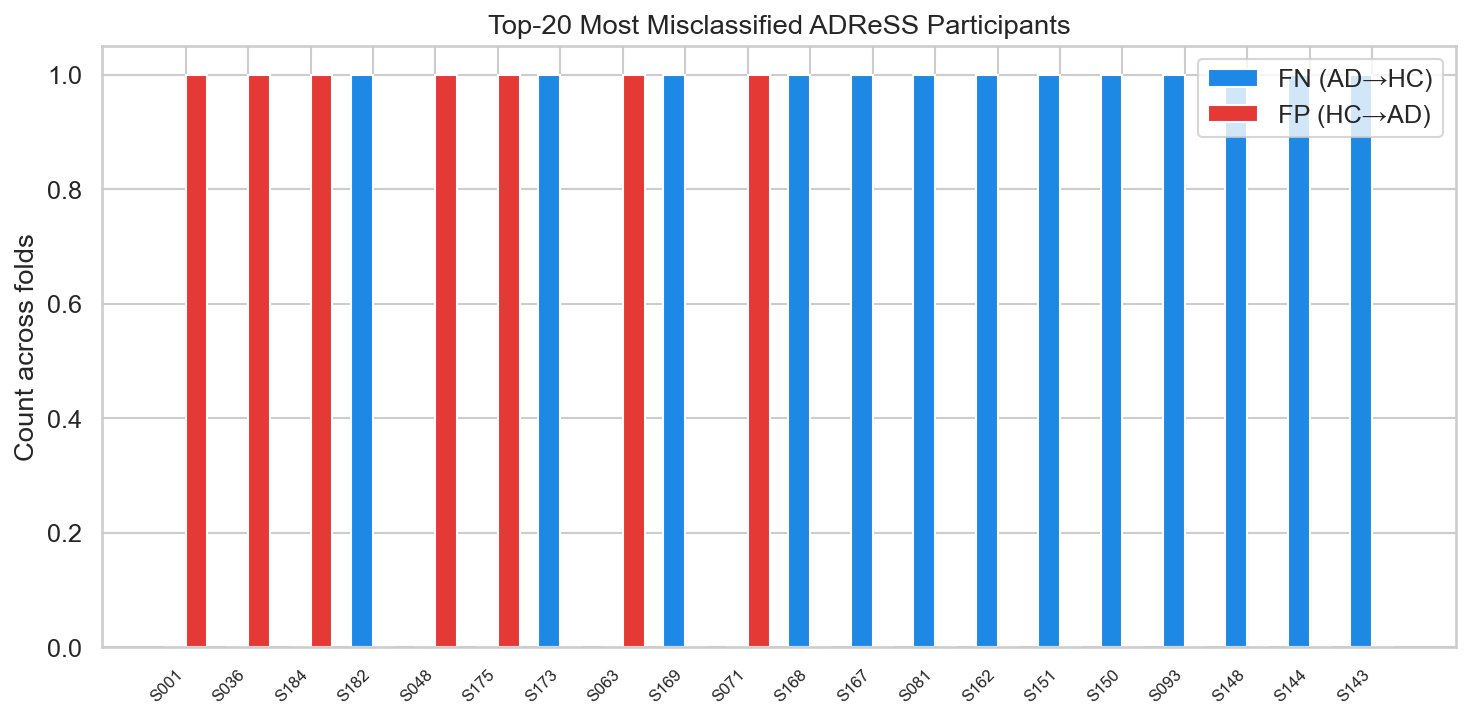

In [6]:
# ── Visualise top-misclassified participants ───────────────────────────────
top20 = misclass_summary[misclass_summary.total_errors > 0].head(20)

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(top20))
w = 0.35
ax.bar(x - w/2, top20['n_fn'], w, label='FN (AD→HC)', color=PALETTE['FN'])
ax.bar(x + w/2, top20['n_fp'], w, label='FP (HC→AD)', color=PALETTE['FP'])
ax.set_xticks(x)
ax.set_xticklabels(top20['participant_id'], rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Count across folds')
ax.set_title('Top-20 Most Misclassified ADReSS Participants')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, 'top_misclassified_participants.png'))
plt.show()

---
## 2. Gender-Based Error Analysis

This is an **exploratory fairness/generalisation analysis**. The ADReSS dataset encodes gender as 0 = male, 1 = female. Any patterns identified should be interpreted cautiously — they reflect the model's behaviour on this specific sample, not biological or clinical claims.

In [7]:
gender_rows = []
for gender_val, gender_name in [(0, 'male'), (1, 'female')]:
    g = pred_df[pred_df['gender'] == gender_val]
    TP = (g['outcome'] == 'TP').sum()
    TN = (g['outcome'] == 'TN').sum()
    FP = (g['outcome'] == 'FP').sum()
    FN = (g['outcome'] == 'FN').sum()
    total = len(g)

    fpr = FP / (FP + TN) if (FP + TN) > 0 else np.nan
    fnr = FN / (FN + TP) if (FN + TP) > 0 else np.nan
    acc = (TP + TN) / total if total > 0 else np.nan
    prec = TP / (TP + FP) if (TP + FP) > 0 else np.nan
    rec  = TP / (TP + FN) if (TP + FN) > 0 else np.nan
    f1   = (2 * prec * rec / (prec + rec)) if (prec and rec and (prec + rec) > 0) else np.nan

    gender_rows.append({
        'gender': gender_name, 'n_samples': total,
        'TP': TP, 'TN': TN, 'FP': FP, 'FN': FN,
        'false_positive_rate': round(fpr, 4),
        'false_negative_rate': round(fnr, 4),
        'accuracy':  round(acc,  4),
        'precision': round(prec, 4),
        'recall':    round(rec,  4),
        'f1':        round(f1,   4),
    })

gender_df = pd.DataFrame(gender_rows)
save_path = os.path.join(OUTPUT_DIR, 'adress_gender_error_analysis.csv')
gender_df.to_csv(save_path, index=False)
print(f'Saved → {save_path}')
display(gender_df)

Saved → /Users/gloria/Documents/uniproject/thesis/outputs/error_analysis_results/adress_gender_error_analysis.csv


,gender,n_samples,TP,TN,FP,FN,false_positive_rate,false_negative_rate,accuracy,precision,recall,f1
0,male,70,23,26,9,12,0.2571,0.3429,0.7000,0.7188,0.6571,0.6866
1,female,86,31,38,5,12,0.1163,0.2791,0.8023,0.8611,0.7209,0.7848


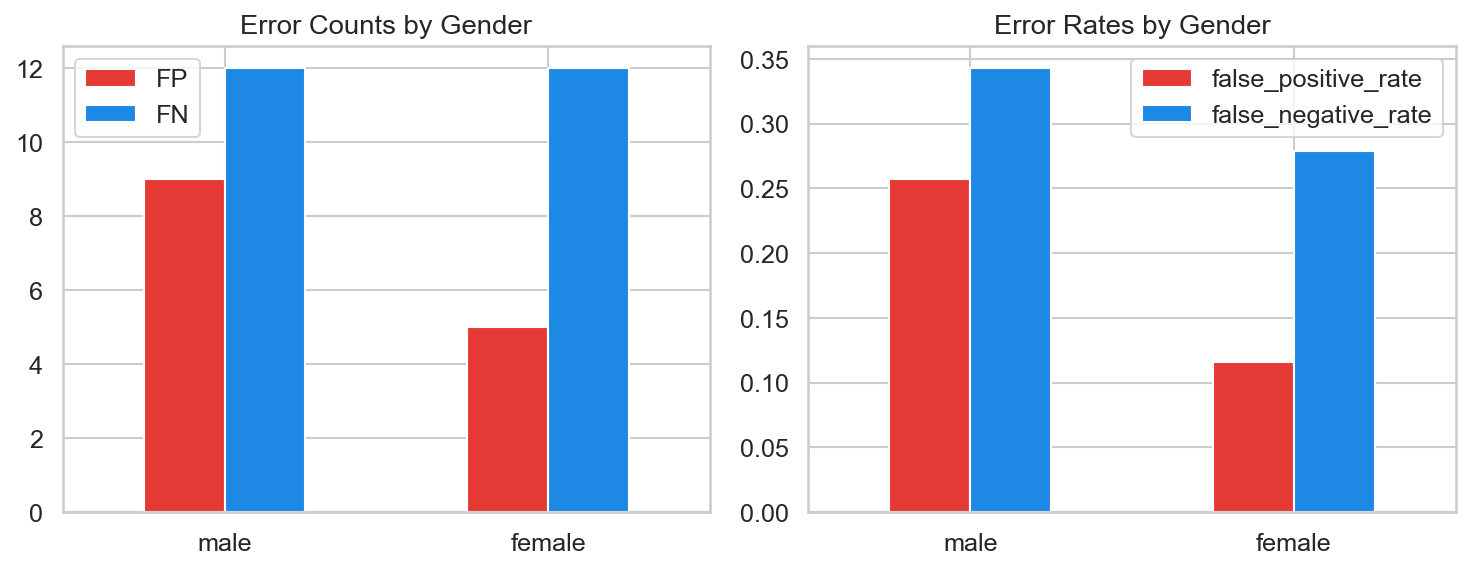

In [8]:
# ── FP/FN by gender bar chart ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=False)

for ax, metric, title in zip(
    axes,
    [['FP', 'FN'], ['false_positive_rate', 'false_negative_rate']],
    ['Error Counts by Gender', 'Error Rates by Gender']
):
    gdf = gender_df.set_index('gender')[metric]
    gdf.plot(kind='bar', ax=ax,
             color=[PALETTE['FP'], PALETTE['FN']], edgecolor='white',
             rot=0)
    ax.set_title(title)
    ax.set_xlabel('')
    ax.legend(metric)

plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, 'gender_error_analysis.png'))
plt.show()

---
## 3. Feature-Based Error Pattern Analysis

We compare mean feature values for:
- **FP vs TN** (HC participants — what distinguishes incorrectly labelled HC from correctly labelled HC?)
- **FN vs TP** (AD participants — what distinguishes missed AD from correctly labelled AD?)

In [9]:
# Collapse per-fold predictions to majority-vote outcome per subject
subj_outcome = subj_agg.copy()
subj_outcome['majority_outcome'] = subj_outcome.apply(
    lambda r: (
        'FN' if r['n_fn'] > r['n_tp'] else
        'TP' if r['true_label'] == 1 else
        'FP' if r['n_fp'] > r['n_tn'] else 'TN'
    ), axis=1
)
subj_feat = subj_outcome.merge(
    df[['ID'] + feature_cols], left_on='participant_id', right_on='ID', how='left'
)

pattern_rows = []
for comparison, group_a, group_b in [
    ('FP_vs_TN', 'FP', 'TN'),
    ('FN_vs_TP', 'FN', 'TP'),
]:
    a = subj_feat[subj_feat['majority_outcome'] == group_a][feature_cols]
    b = subj_feat[subj_feat['majority_outcome'] == group_b][feature_cols]
    for feat in feature_cols:
        pattern_rows.append({
            'comparison': comparison,
            'feature':    feat,
            f'mean_{group_a}': round(a[feat].mean(), 4),
            f'mean_{group_b}': round(b[feat].mean(), 4),
            f'std_{group_a}':  round(a[feat].std(),  4),
            f'std_{group_b}':  round(b[feat].std(),  4),
            'abs_diff': round(abs(a[feat].mean() - b[feat].mean()), 4),
        })

pattern_df = pd.DataFrame(pattern_rows)
save_path = os.path.join(OUTPUT_DIR, 'adress_feature_error_patterns.csv')
pattern_df.to_csv(save_path, index=False)
print(f'Saved → {save_path}')

print('\n--- Top FP vs TN feature differences ---')
display(pattern_df[pattern_df.comparison=='FP_vs_TN'].sort_values('abs_diff', ascending=False).head(10))
print('\n--- Top FN vs TP feature differences ---')
display(pattern_df[pattern_df.comparison=='FN_vs_TP'].sort_values('abs_diff', ascending=False).head(10))

Saved → /Users/gloria/Documents/uniproject/thesis/outputs/error_analysis_results/adress_feature_error_patterns.csv

--- Top FP vs TN feature differences ---


,comparison,feature,mean_FP,mean_TN,std_FP,std_TN,abs_diff,mean_FN,mean_TP,std_FN,std_TP
33,FP_vs_TN,n_part,3.3571,1.7812,3.1282,1.5983,1.5759,NaN,NaN,NaN,NaN
5,FP_vs_TN,tokens_per_sentence,10.7625,11.4814,6.6407,5.6741,0.7189,NaN,NaN,NaN,NaN
39,FP_vs_TN,pronoun_noun_ratio,0.7964,0.5349,0.2933,0.2654,0.2616,NaN,NaN,NaN,NaN
34,FP_vs_TN,n_aux,9.1429,8.9531,6.6663,4.6953,0.1897,NaN,NaN,NaN,NaN
42,FP_vs_TN,noun_verb_ratio,1.1303,1.3149,0.3680,0.4377,0.1846,NaN,NaN,NaN,NaN
40,FP_vs_TN,verb_noun_ratio,0.8638,0.7416,0.2820,0.2454,0.1223,NaN,NaN,NaN,NaN
7,FP_vs_TN,avg_concreteness,3.1525,3.2580,0.1516,0.1812,0.1055,NaN,NaN,NaN,NaN
14,FP_vs_TN,avg_Interoceptive_sensorimotor,1.0958,1.0057,0.1437,0.1246,0.0901,NaN,NaN,NaN,NaN
45,FP_vs_TN,particle_verb_ratio,0.1858,0.1050,0.1132,0.0793,0.0808,NaN,NaN,NaN,NaN
44,FP_vs_TN,aux_verb_ratio,0.4631,0.5397,0.1947,0.2014,0.0765,NaN,NaN,NaN,NaN



--- Top FN vs TP feature differences ---


,comparison,feature,mean_FP,mean_TN,std_FP,std_TN,abs_diff,mean_FN,mean_TP,std_FN,std_TP
80,FN_vs_TP,n_aux,NaN,NaN,NaN,NaN,3.0093,8.7500,5.7407,8.2211,3.9677
51,FN_vs_TP,tokens_per_sentence,NaN,NaN,NaN,NaN,0.9476,10.0066,9.0589,4.1626,2.5303
79,FN_vs_TP,n_part,NaN,NaN,NaN,NaN,0.4352,2.9167,2.4815,3.3482,2.1434
71,FN_vs_TP,tree_depth,NaN,NaN,NaN,NaN,0.2110,2.8339,2.6229,0.5503,0.5792
87,FN_vs_TP,filler_to_noun_ratio,NaN,NaN,NaN,NaN,0.2044,0.2791,0.4834,0.2604,0.3925
53,FN_vs_TP,avg_concreteness,NaN,NaN,NaN,NaN,0.1584,3.1956,3.0373,0.2366,0.2274
85,FN_vs_TP,pronoun_noun_ratio,NaN,NaN,NaN,NaN,0.1533,0.8625,1.0158,0.6101,0.6992
46,FN_vs_TP,avg_word_length,NaN,NaN,NaN,NaN,0.1456,3.4187,3.2731,0.2077,0.2173
62,FN_vs_TP,avg_Visual_sensorimotor,NaN,NaN,NaN,NaN,0.1036,2.9274,2.8238,0.2414,0.2110
90,FN_vs_TP,aux_verb_ratio,NaN,NaN,NaN,NaN,0.0976,0.4854,0.3878,0.2220,0.2163


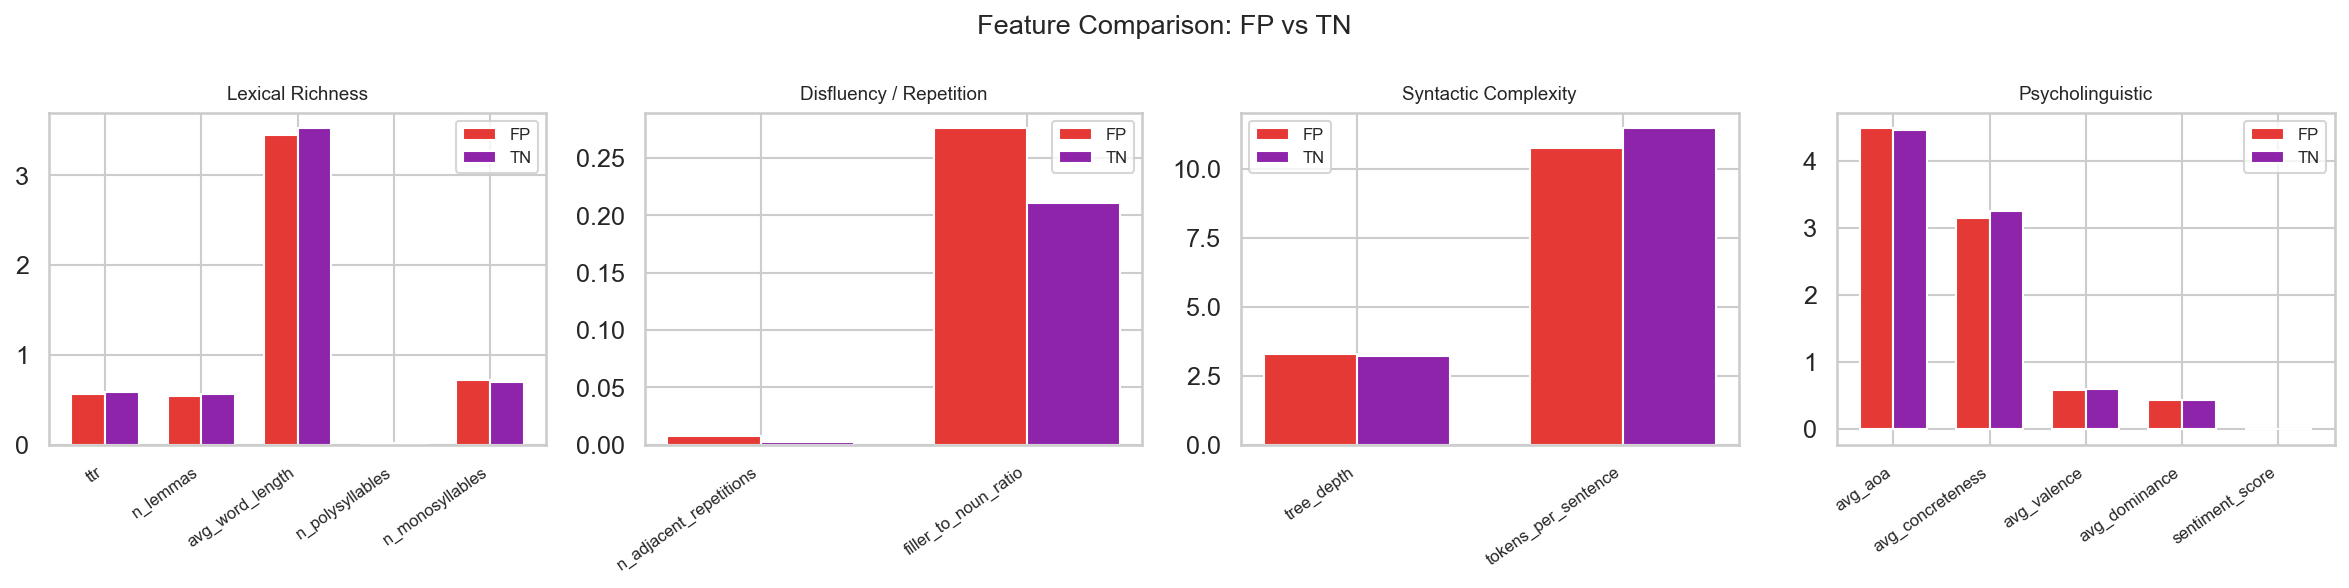

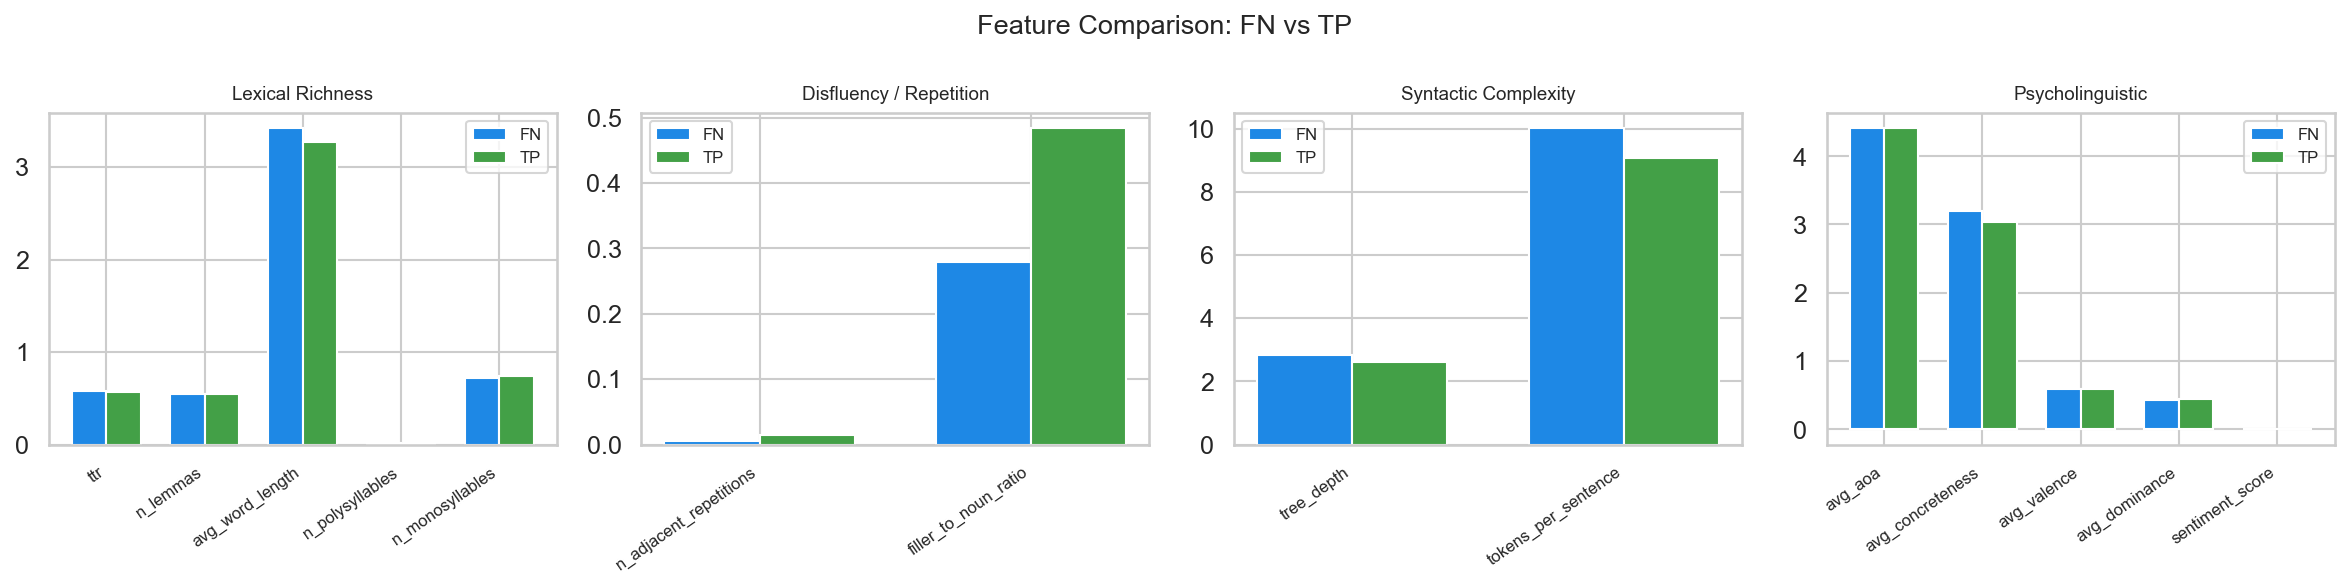

In [10]:
# ── Grouped feature difference bar charts ────────────────────────────────
# Focus: lexical richness, disfluency, syntactic complexity, psycholinguistic
FEATURE_GROUPS = {
    'Lexical Richness': ['ttr', 'n_lemmas', 'avg_word_length', 'n_polysyllables', 'n_monosyllables'],
    'Disfluency / Repetition': ['n_adjacent_repetitions', 'filler_to_noun_ratio'],
    'Syntactic Complexity': ['tree_depth', 'tokens_per_sentence', 'n_utterances'],
    'Psycholinguistic': ['avg_aoa', 'avg_concreteness', 'avg_valence', 'avg_dominance', 'sentiment_score'],
}

for comp_label, grp_a, grp_b in [('FP_vs_TN', 'FP', 'TN'), ('FN_vs_TP', 'FN', 'TP')]:
    sub = pattern_df[pattern_df.comparison == comp_label].set_index('feature')
    fig, axes = plt.subplots(1, len(FEATURE_GROUPS), figsize=(16, 4))
    fig.suptitle(f'Feature Comparison: {grp_a} vs {grp_b}', fontsize=13)
    for ax, (grp_name, feats) in zip(axes, FEATURE_GROUPS.items()):
        feats_ok = [f for f in feats if f in sub.index]
        if not feats_ok:
            ax.set_visible(False)
            continue
        vals_a = sub.loc[feats_ok, f'mean_{grp_a}']
        vals_b = sub.loc[feats_ok, f'mean_{grp_b}']
        x = np.arange(len(feats_ok))
        w = 0.35
        ax.bar(x - w/2, vals_a, w, label=grp_a, color=PALETTE[grp_a])
        ax.bar(x + w/2, vals_b, w, label=grp_b, color=PALETTE[grp_b])
        ax.set_xticks(x)
        ax.set_xticklabels(feats_ok, rotation=35, ha='right', fontsize=8)
        ax.set_title(grp_name, fontsize=9)
        ax.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(os.path.join(VIZ_DIR, f'feature_comparison_{comp_label}.png'))
    plt.show()

---
## 4. Transcript-Length / Complexity Analysis

We examine whether model errors correlate with transcript length or linguistic complexity. Proxy measures available in the feature set: `n_utterances` (utterance count), `tokens_per_sentence`, `ttr` (lexical diversity).

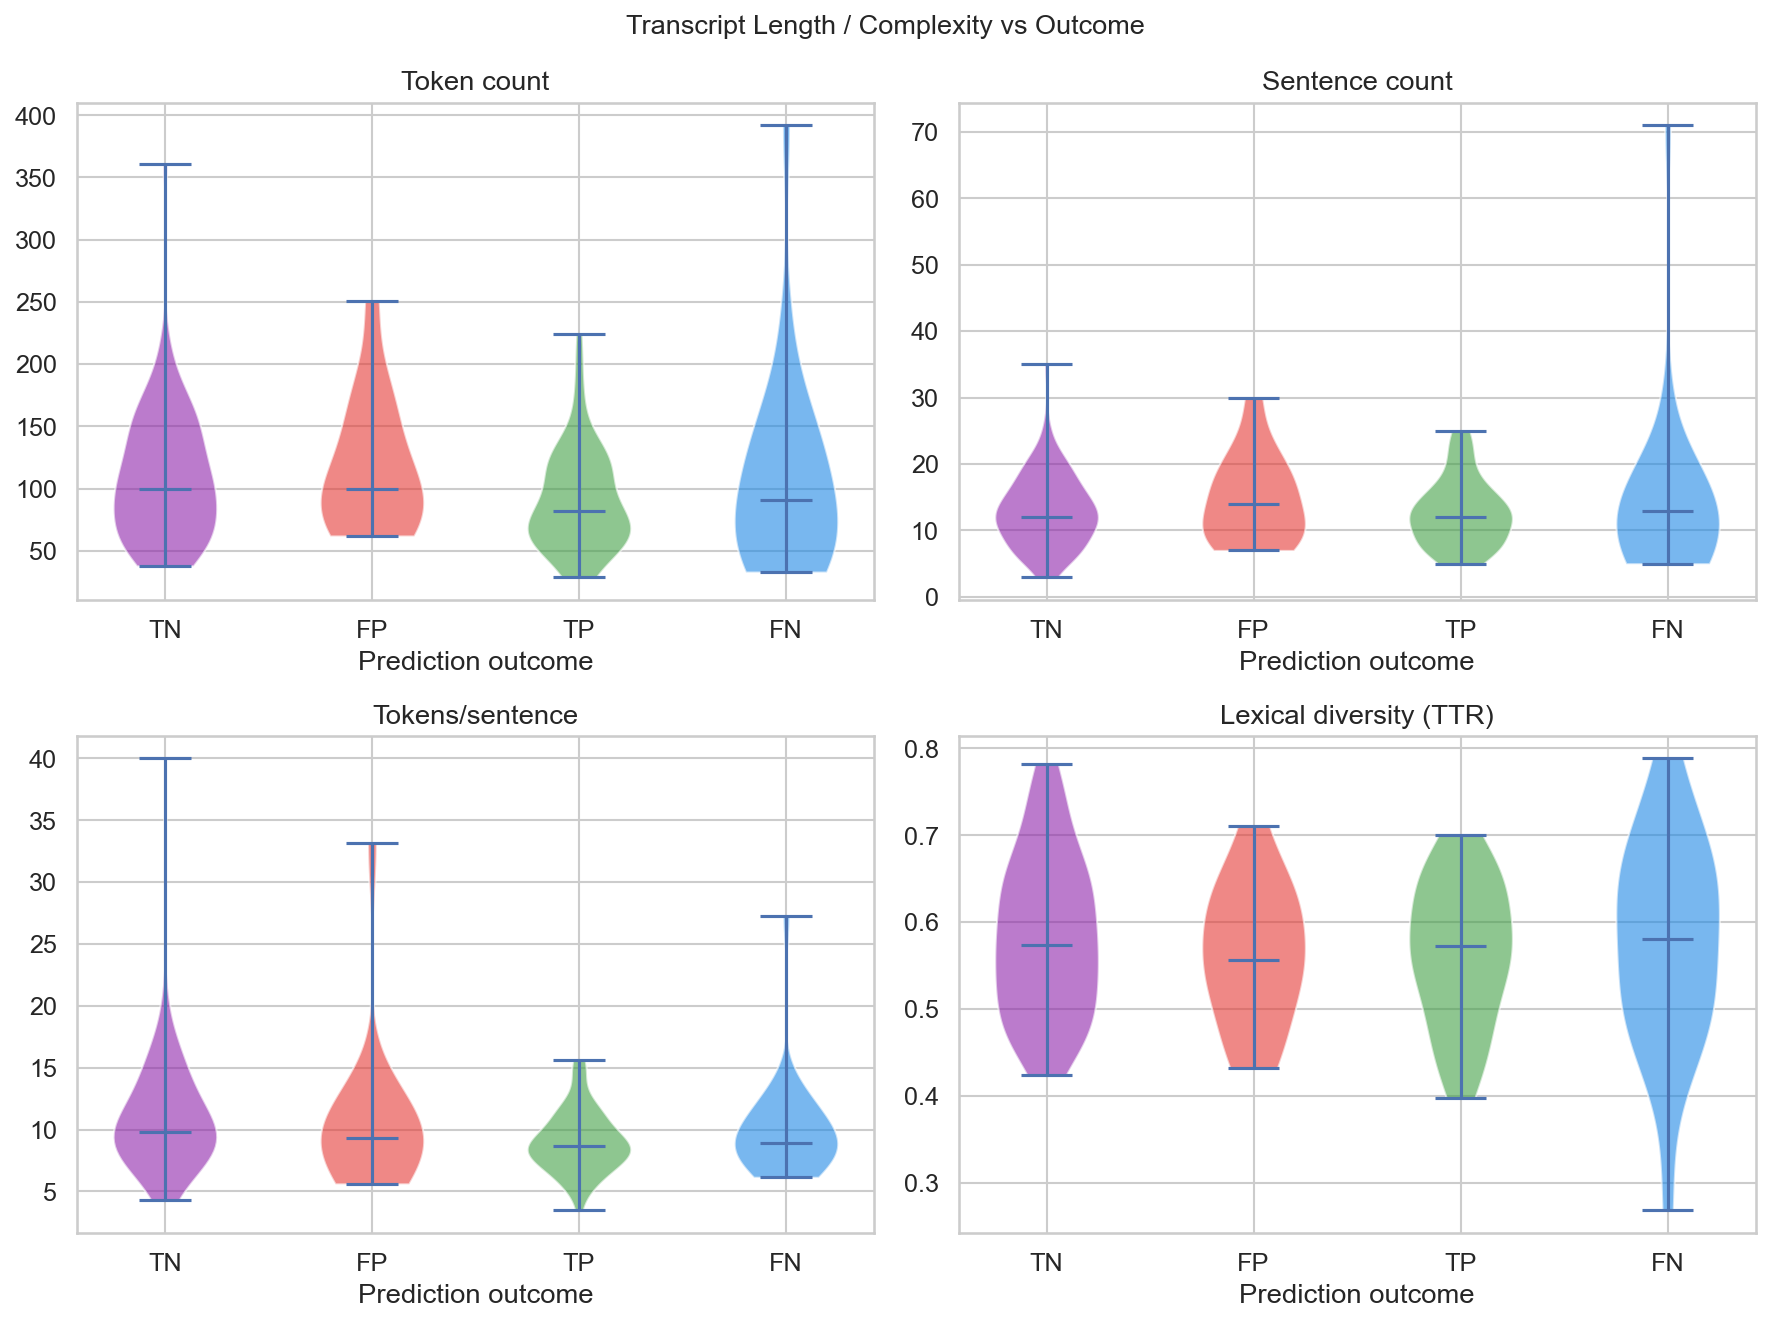

In [12]:
# Approximate token count from aggregated_utterances text
df['approx_token_count'] = df['aggregated_utterances'].fillna('').apply(
    lambda s: len(str(s).split())
)

# n_utterances lives in adress_clean.csv, not in the extracted-features CSV
CLEAN_PATH = os.path.join(BASE_DIR, 'data', 'adress_clean.csv')
df_clean   = pd.read_csv(CLEAN_PATH)[['ID', 'n_utterances']]
df         = df.merge(df_clean, on='ID', how='left')
df['sentence_count'] = df['n_utterances']

subj_len = subj_feat.merge(
    df[['ID', 'approx_token_count', 'sentence_count']],
    left_on='participant_id', right_on='ID', how='left'
)
subj_len['outcome_label'] = subj_len['majority_outcome']

LENGTH_FEATURES = {
    'Token count':             'approx_token_count',
    'Sentence count':          'sentence_count',
    'Tokens/sentence':         'tokens_per_sentence',
    'Lexical diversity (TTR)': 'ttr',
}

order  = ['TN', 'FP', 'TP', 'FN']
colors = [PALETTE['TN'], PALETTE['FP'], PALETTE['TP'], PALETTE['FN']]

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
fig.suptitle('Transcript Length / Complexity vs Outcome', fontsize=13)

for ax, (lbl, col) in zip(axes.flatten(), LENGTH_FEATURES.items()):
    if col not in subj_len.columns:
        ax.set_visible(False)
        continue
    plot_data = [subj_len.loc[subj_len['outcome_label'] == o, col].dropna().values
                 for o in order]
    vp = ax.violinplot(plot_data, positions=range(len(order)),
                       showmedians=True, showextrema=True)
    for body, c in zip(vp['bodies'], colors):
        body.set_facecolor(c)
        body.set_alpha(0.6)
    ax.set_xticks(range(len(order)))
    ax.set_xticklabels(order)
    ax.set_title(lbl)
    ax.set_xlabel('Prediction outcome')

plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, 'transcript_length_vs_outcome_violin.png'))
plt.show()

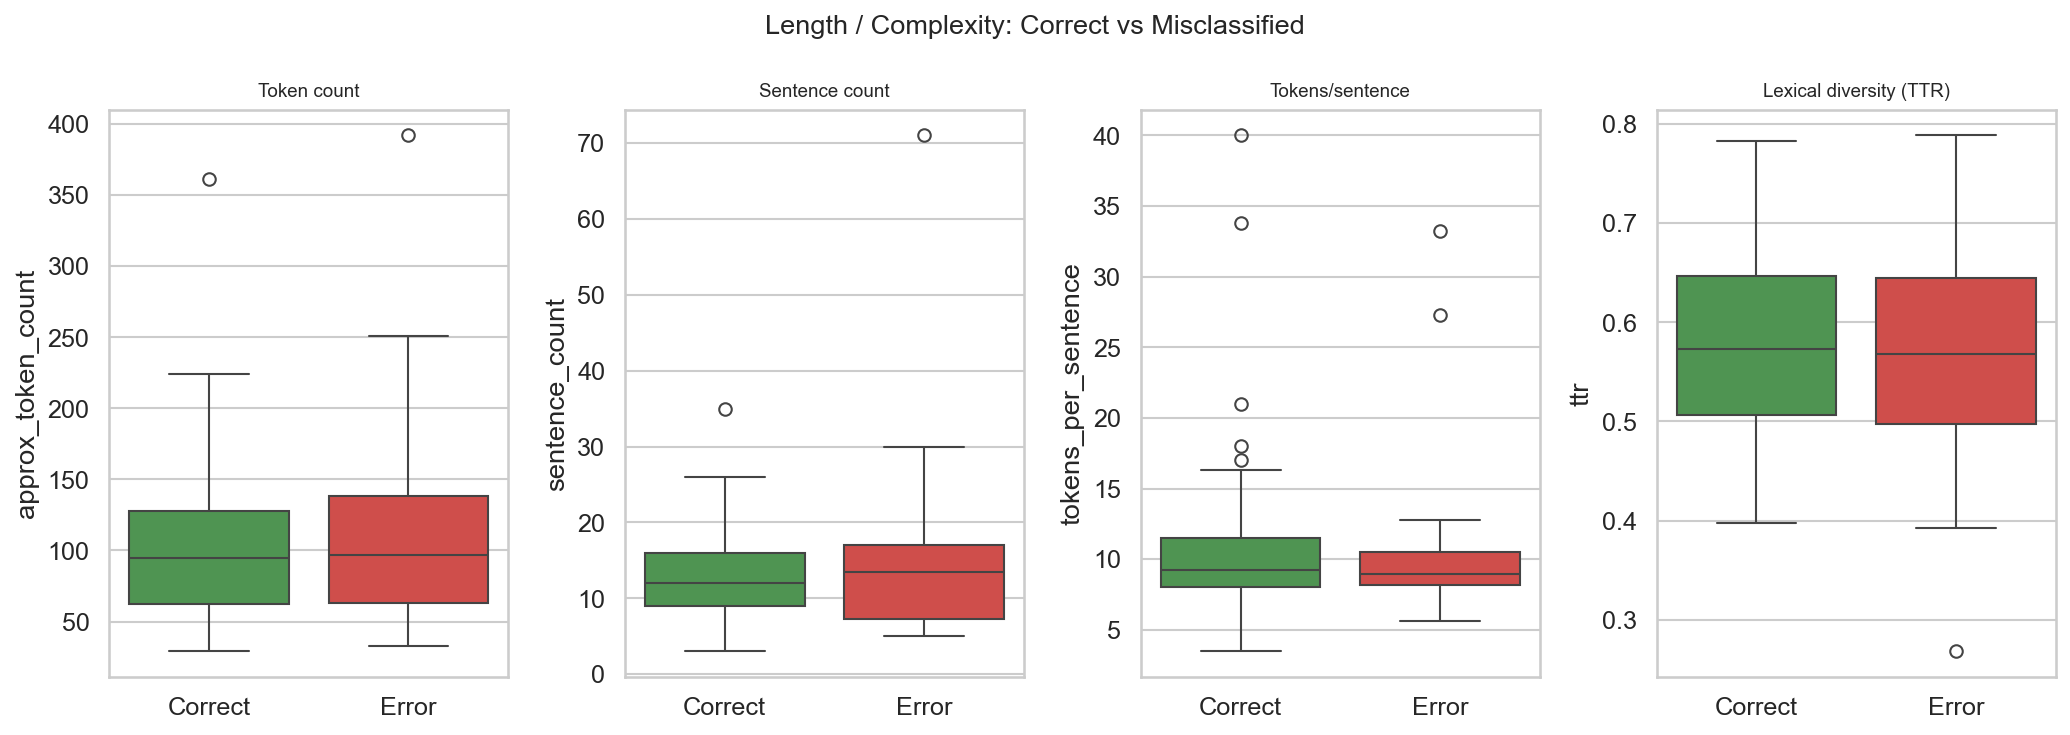

In [13]:
# ── Boxplots — correct vs error ───────────────────────────────────────────
subj_len['classified_correctly'] = subj_len['majority_outcome'].isin(['TP', 'TN'])
subj_len['classification_result'] = subj_len['classified_correctly'].map(
    {True: 'Correct', False: 'Error'}
)

fig, axes = plt.subplots(1, 4, figsize=(14, 5))
fig.suptitle('Length / Complexity: Correct vs Misclassified', fontsize=13)
for ax, (lbl, col) in zip(axes, LENGTH_FEATURES.items()):
    if col not in subj_len.columns:
        ax.set_visible(False)
        continue
    sns.boxplot(data=subj_len, x='classification_result', y=col,
                palette=[PALETTE['correct'], PALETTE['error']],
                order=['Correct', 'Error'], ax=ax)
    ax.set_title(lbl, fontsize=9)
    ax.set_xlabel('')

plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, 'transcript_length_correct_vs_error_box.png'))
plt.show()

---
## 5. Qualitative Case Analysis

Representative FP and FN participants are examined in detail. For each case we print key feature values, compare against dataset averages, and provide a brief explanation of likely model failure modes.

In [14]:
dataset_means = df[feature_cols].mean().rename('dataset_mean')
dataset_stds  = df[feature_cols].std().rename('dataset_std')

KEY_FEATURES = [
    'ttr', 'n_lemmas', 'avg_word_length',
    'n_adjacent_repetitions', 'filler_to_noun_ratio',
    'tree_depth', 'tokens_per_sentence',
    'avg_aoa', 'avg_concreteness', 'avg_valence',
]

def qualitative_case(participant_id, outcome_type, df_full, dataset_means, dataset_stds, key_feats):
    row = df_full[df_full['ID'] == participant_id].iloc[0]
    diag = 'AD' if row['diagnosis'] == 1 else 'HC'
    gen  = 'female' if row['gender'] == 1 else 'male'
    print(f'\n{'='*60}')
    print(f'Participant: {participant_id}  |  True: {diag}  |  Outcome: {outcome_type}  |  Gender: {gen}')
    if pd.notna(row.get('mmse')):
        print(f'MMSE: {row["mmse"]}')
    print(f'{'='*60}')
    rows = []
    for f in key_feats:
        if f not in row.index:
            continue
        val   = row[f]
        mu    = dataset_means[f]
        sigma = dataset_stds[f]
        z     = (val - mu) / sigma if sigma > 0 else 0
        direction = 'above' if z > 0 else 'below'
        rows.append({'feature': f, 'value': round(val, 3),
                     'dataset_mean': round(mu, 3),
                     'z_score': round(z, 2), 'vs_mean': direction})
    tbl = pd.DataFrame(rows).sort_values('z_score', key=abs, ascending=False)
    display(tbl)

# ── Select representative cases ───────────────────────────────────────────
# Worst FP: HC predicted as AD most often
fp_cases = misclass_summary[misclass_summary['n_fp'] > 0].sort_values('n_fp', ascending=False)
fn_cases = misclass_summary[misclass_summary['n_fn'] > 0].sort_values('n_fn', ascending=False)

n_examples = 2
print('\n### FALSE POSITIVES (HC participants predicted as AD) ###')
for pid in fp_cases['participant_id'].head(n_examples):
    qualitative_case(pid, 'FP', df, dataset_means, dataset_stds, KEY_FEATURES)

print('\n\n### FALSE NEGATIVES (AD participants predicted as HC) ###')
for pid in fn_cases['participant_id'].head(n_examples):
    qualitative_case(pid, 'FN', df, dataset_means, dataset_stds, KEY_FEATURES)


### FALSE POSITIVES (HC participants predicted as AD) ###

Participant: S001  |  True: HC  |  Outcome: FP  |  Gender: male


,feature,value,dataset_mean,z_score,vs_mean
5,tree_depth,8.200,2.951,6.35,above
6,tokens_per_sentence,33.200,10.351,4.80,above
7,avg_aoa,4.710,4.444,1.36,above
2,avg_word_length,3.657,3.413,1.12,above
1,n_lemmas,0.470,0.549,-0.82,below
3,n_adjacent_repetitions,0.018,0.008,0.80,above
9,avg_valence,0.569,0.592,-0.77,below
0,ttr,0.506,0.574,-0.73,below
8,avg_concreteness,3.288,3.163,0.56,above
4,filler_to_noun_ratio,0.300,0.322,-0.07,below



Participant: S036  |  True: HC  |  Outcome: FP  |  Gender: male
MMSE: 28.0


,feature,value,dataset_mean,z_score,vs_mean
8,avg_concreteness,3.487,3.163,1.44,above
2,avg_word_length,3.645,3.413,1.06,above
9,avg_valence,0.571,0.592,-0.72,below
3,n_adjacent_repetitions,0.016,0.008,0.65,above
4,filler_to_noun_ratio,0.172,0.322,-0.51,below
0,ttr,0.540,0.574,-0.36,below
1,n_lemmas,0.516,0.549,-0.34,below
7,avg_aoa,4.419,4.444,-0.13,below
5,tree_depth,3.000,2.951,0.06,above
6,tokens_per_sentence,10.333,10.351,-0.00,below




### FALSE NEGATIVES (AD participants predicted as HC) ###

Participant: S182  |  True: AD  |  Outcome: FN  |  Gender: female
MMSE: 12.0


,feature,value,dataset_mean,z_score,vs_mean
3,n_adjacent_repetitions,0.038,0.008,2.30,above
7,avg_aoa,4.213,4.444,-1.18,below
4,filler_to_noun_ratio,0.059,0.322,-0.89,below
9,avg_valence,0.608,0.592,0.56,above
0,ttr,0.547,0.574,-0.29,below
1,n_lemmas,0.528,0.549,-0.22,below
8,avg_concreteness,3.140,3.163,-0.10,below
5,tree_depth,2.900,2.951,-0.06,below
6,tokens_per_sentence,10.600,10.351,0.05,above
2,avg_word_length,3.415,3.413,0.01,above



Participant: S173  |  True: AD  |  Outcome: FN  |  Gender: female
MMSE: 17.0


,feature,value,dataset_mean,z_score,vs_mean
0,ttr,0.393,0.574,-1.95,below
1,n_lemmas,0.385,0.549,-1.70,below
5,tree_depth,3.455,2.951,0.61,above
3,n_adjacent_repetitions,0.000,0.008,-0.58,below
2,avg_word_length,3.296,3.413,-0.53,below
4,filler_to_noun_ratio,0.190,0.322,-0.44,below
7,avg_aoa,4.528,4.444,0.43,above
6,tokens_per_sentence,12.273,10.351,0.40,above
8,avg_concreteness,3.108,3.163,-0.24,below
9,avg_valence,0.599,0.592,0.23,above


---
## 6. Confusion Matrix Interpretation

This section generates a narrative interpretation of the aggregated confusion matrix, discussing asymmetry, direction of bias, and whether errors appear systematic.

Raw confusion matrix (rows = true label, cols = predicted):
  Pred HC  Pred AD
HC     64      14
AD     24      54

FPR (HC→AD): 0.179  |  FNR (AD→HC): 0.308


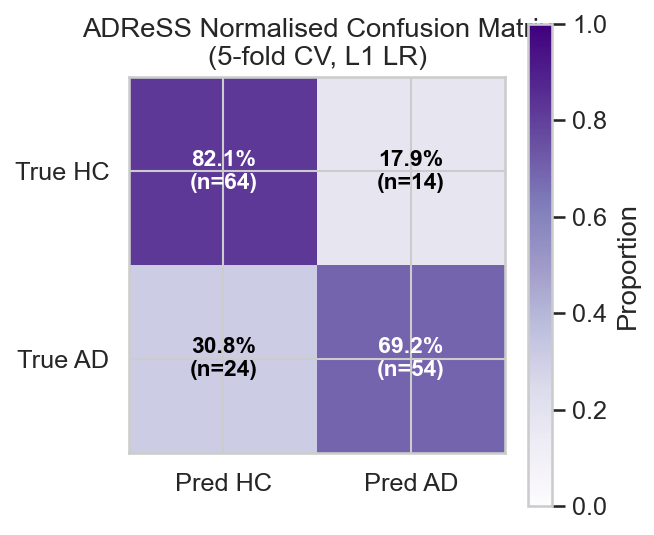

In [15]:
# Rebuild confusion matrix from fold predictions
total_TP = (pred_df['outcome'] == 'TP').sum()
total_TN = (pred_df['outcome'] == 'TN').sum()
total_FP = (pred_df['outcome'] == 'FP').sum()
total_FN = (pred_df['outcome'] == 'FN').sum()

total_HC = total_TN + total_FP
total_AD = total_TP + total_FN

fpr = total_FP / total_HC if total_HC > 0 else 0
fnr = total_FN / total_AD if total_AD > 0 else 0

cm_raw  = np.array([[total_TN, total_FP], [total_FN, total_TP]])
cm_norm = cm_raw.astype(float) / cm_raw.sum(axis=1, keepdims=True)

print(f'Raw confusion matrix (rows = true label, cols = predicted):')
print(f'  Pred HC  Pred AD')
print(f'HC   {total_TN:4d}    {total_FP:4d}')
print(f'AD   {total_FN:4d}    {total_TP:4d}')
print(f'\nFPR (HC→AD): {fpr:.3f}  |  FNR (AD→HC): {fnr:.3f}')

# ── Normalised confusion matrix plot ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(4.5, 4))
im = ax.imshow(cm_norm, cmap='Purples', vmin=0, vmax=1)
labels = ['HC', 'AD']
for i in range(2):
    for j in range(2):
        pct = cm_norm[i, j] * 100
        cnt = cm_raw[i, j]
        col = 'white' if cm_norm[i, j] > 0.55 else 'black'
        ax.text(j, i, f'{pct:.1f}%\n(n={cnt})',
                ha='center', va='center', fontsize=11, fontweight='bold', color=col)
ax.set_xticks([0, 1]); ax.set_xticklabels(['Pred HC', 'Pred AD'])
ax.set_yticks([0, 1]); ax.set_yticklabels(['True HC', 'True AD'])
ax.set_title('ADReSS Normalised Confusion Matrix\n(5-fold CV, L1 LR)')
plt.colorbar(im, ax=ax, label='Proportion')
plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, 'adress_confusion_matrix_error_analysis.png'))
plt.show()

In [16]:
# ── Narrative interpretation ──────────────────────────────────────────────

asymmetry = abs(fpr - fnr)
bias_direction = 'over-predicts AD (more FPs)' if fpr > fnr else 'misses AD cases (more FNs)'
dominant_error = 'FP' if total_FP > total_FN else 'FN'

# Check if errors cluster by gender
fp_gender = pred_df[pred_df.outcome=='FP']['gender'].value_counts(normalize=True)
fn_gender = pred_df[pred_df.outcome=='FN']['gender'].value_counts(normalize=True)

interpretation = f"""
CONFUSION MATRIX INTERPRETATION
================================

Overall error asymmetry
------------------------
The model produced {total_FP} false positives (FPR = {fpr:.1%}) and {total_FN} false negatives
(FNR = {fnr:.1%}) across the 5-fold CV. The dominant error type is {dominant_error}, meaning the
model {bias_direction}. The asymmetry between FPR and FNR is {asymmetry:.3f}.

This pattern is consistent with a classifier trained with class_weight='balanced': the balancing
prevents extreme suppression of the minority class but can shift the decision boundary in ways
that introduce FPs when the feature distributions overlap.

AD detection
------------
The recall for AD is {total_TP/(total_TP+total_FN):.1%}, meaning the model correctly identifies
{total_TP} of the {total_AD} AD cases. The {total_FN} missed AD cases (FN) represent participants
whose linguistic profiles are atypically preserved — feature values closer to the HC distribution.
These are clinically the most consequential errors.

Systematic vs. random errors
----------------------------
{'Errors appear somewhat systematic — certain participants are repeatedly misclassified across folds (see Section 1), suggesting these are genuinely borderline cases rather than random noise.' if misclass_summary[misclass_summary.total_errors >= 2].shape[0] > 0 else 'Errors appear largely unsystematic — most participants are misclassified in at most one fold.'}

Gender breakdown of errors
--------------------------
Among FP errors: {fp_gender.get(1, 0):.0%} female, {fp_gender.get(0, 0):.0%} male.
Among FN errors: {fn_gender.get(1, 0):.0%} female, {fn_gender.get(0, 0):.0%} male.
This should be interpreted as an exploratory observation, not a causal finding.
"""

print(interpretation)
with open(os.path.join(OUTPUT_DIR, 'confusion_matrix_interpretation.txt'), 'w') as f:
    f.write(interpretation)
print(f'Saved → {os.path.join(OUTPUT_DIR, "confusion_matrix_interpretation.txt")}')


CONFUSION MATRIX INTERPRETATION

Overall error asymmetry
------------------------
The model produced 14 false positives (FPR = 17.9%) and 24 false negatives
(FNR = 30.8%) across the 5-fold CV. The dominant error type is FN, meaning the
model misses AD cases (more FNs). The asymmetry between FPR and FNR is 0.128.

This pattern is consistent with a classifier trained with class_weight='balanced': the balancing
prevents extreme suppression of the minority class but can shift the decision boundary in ways
that introduce FPs when the feature distributions overlap.

AD detection
------------
The recall for AD is 69.2%, meaning the model correctly identifies
54 of the 78 AD cases. The 24 missed AD cases (FN) represent participants
whose linguistic profiles are atypically preserved — feature values closer to the HC distribution.
These are clinically the most consequential errors.

Systematic vs. random errors
----------------------------
Errors appear largely unsystematic — most participants 

---
## 7. Cross-Domain Error Interpretation

We use the already-computed cross-domain results to discuss **why** out-of-domain errors increase. The key comparisons are:
- **adress_to_ccc**: train on ADReSS, test on CCC
- **ccc_to_adress**: train on CCC, test on ADReSS

In [17]:
cm_cross = pd.read_csv(os.path.join(CROSS_DIR, 'confusion_matrices.csv'))
cm_cross = cm_cross[cm_cross['experiment'].isin(['adress_to_ccc', 'ccc_to_adress'])].copy()

# Compute FPR / FNR for cross-domain results
cm_cross['FPR'] = cm_cross['FP'] / (cm_cross['FP'] + cm_cross['TN'])
cm_cross['FNR'] = cm_cross['FN'] / (cm_cross['FN'] + cm_cross['TP'])
cm_cross['accuracy'] = (cm_cross['TP'] + cm_cross['TN']) / (
    cm_cross['TP'] + cm_cross['TN'] + cm_cross['FP'] + cm_cross['FN']
)

display(cm_cross[['experiment', 'feature_set', 'TN', 'FP', 'FN', 'TP', 'FPR', 'FNR', 'accuracy']].round(3))

# In-domain reference
indomain_fpr = fpr
indomain_fnr = fnr
indomain_acc = (total_TP + total_TN) / (total_TP + total_TN + total_FP + total_FN)

print(f'\nIn-domain (ADReSS 5-fold CV):')
print(f'  FPR={indomain_fpr:.3f}  FNR={indomain_fnr:.3f}  Accuracy={indomain_acc:.3f}')

,experiment,feature_set,TN,FP,FN,TP,FPR,FNR,accuracy
0,adress_to_ccc,joint_top_features,141,52,67,30,0.269,0.691,0.590
1,adress_to_ccc,shared_features,113,80,67,30,0.415,0.691,0.493
2,adress_to_ccc,shared_relaxed_features,114,79,67,30,0.409,0.691,0.497
3,ccc_to_adress,joint_top_features,78,0,75,3,0.000,0.962,0.519
4,ccc_to_adress,shared_features,76,2,64,14,0.026,0.821,0.577
5,ccc_to_adress,shared_relaxed_features,76,2,66,12,0.026,0.846,0.564



In-domain (ADReSS 5-fold CV):
  FPR=0.179  FNR=0.308  Accuracy=0.756


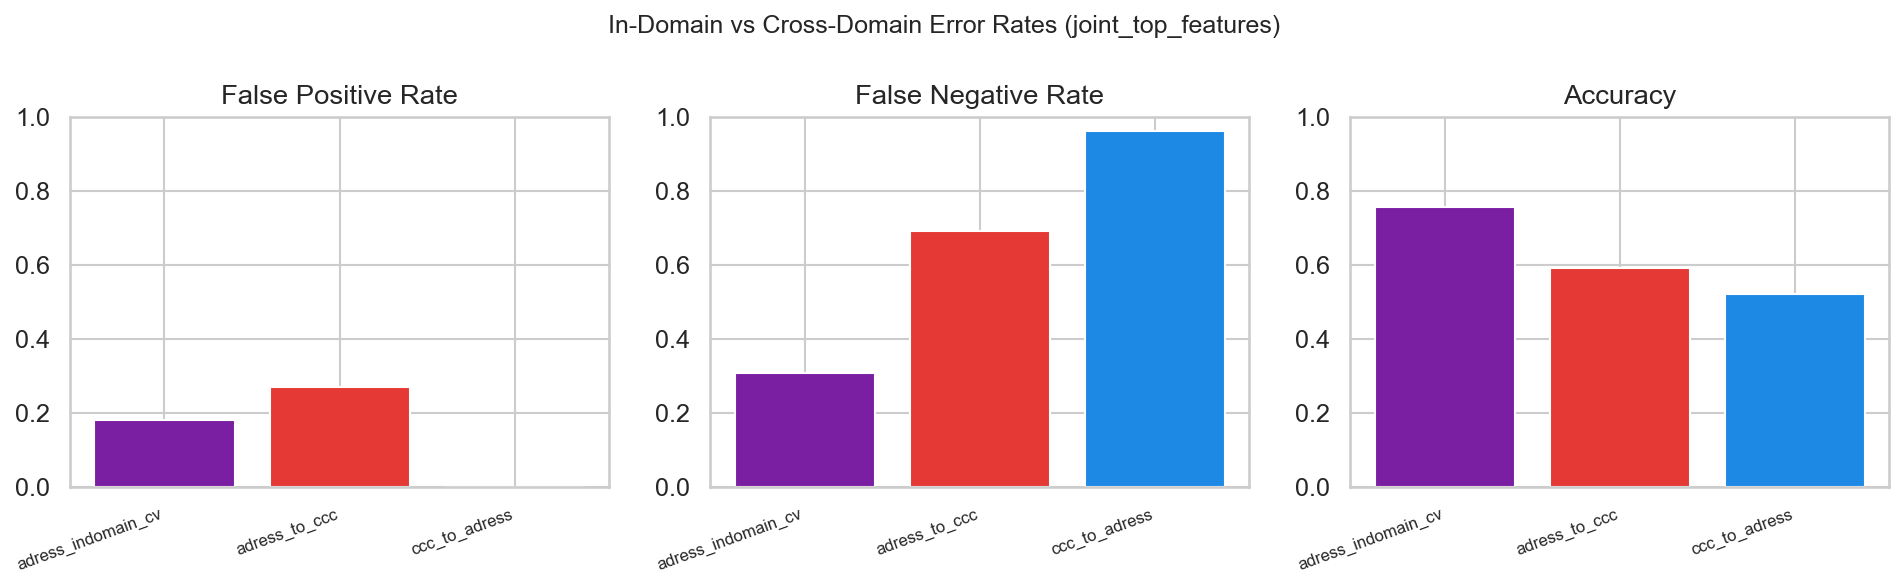

In [18]:
# ── Cross-domain FPR / FNR comparison chart ───────────────────────────────
joint_row = cm_cross[cm_cross['feature_set'] == 'joint_top_features'].copy()

# Add in-domain row for comparison
indomain_row = pd.DataFrame([{
    'experiment': 'adress_indomain_cv',
    'FPR': indomain_fpr, 'FNR': indomain_fnr, 'accuracy': indomain_acc
}])
compare = pd.concat([indomain_row, joint_row[['experiment', 'FPR', 'FNR', 'accuracy']]], ignore_index=True)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, metric, title in zip(axes, ['FPR', 'FNR', 'accuracy'],
                              ['False Positive Rate', 'False Negative Rate', 'Accuracy']):
    colors_bar = ['#7B1FA2' if 'indomain' in e else
                  '#E53935' if 'adress_to_ccc' in e else '#1E88E5'
                  for e in compare['experiment']]
    ax.bar(compare['experiment'], compare[metric], color=colors_bar, edgecolor='white')
    ax.set_title(title)
    ax.set_xticklabels(compare['experiment'], rotation=20, ha='right', fontsize=8)
    ax.set_ylim(0, 1)

plt.suptitle('In-Domain vs Cross-Domain Error Rates (joint_top_features)', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, 'cross_domain_error_comparison.png'))
plt.show()

In [19]:
# ── Cross-domain narrative interpretation ────────────────────────────────

# CCC-to-ADReSS joint features row
ccc_to_adress = joint_row[joint_row.experiment == 'ccc_to_adress'].iloc[0] if 'ccc_to_adress' in joint_row.experiment.values else None
adress_to_ccc = joint_row[joint_row.experiment == 'adress_to_ccc'].iloc[0] if 'adress_to_ccc' in joint_row.experiment.values else None

cross_interpretation = f"""
CROSS-DOMAIN ERROR INTERPRETATION
==================================

In-domain baseline (ADReSS 5-fold CV)
  Accuracy = {indomain_acc:.3f} | FPR = {indomain_fpr:.3f} | FNR = {indomain_fnr:.3f}
"""

if adress_to_ccc is not None:
    cross_interpretation += f"""
ADReSS → CCC (joint_top_features)
  Accuracy = {adress_to_ccc['accuracy']:.3f} | FPR = {adress_to_ccc['FPR']:.3f} | FNR = {adress_to_ccc['FNR']:.3f}
  Performance drops substantially when ADReSS-trained features are applied to CCC.
  The increased FNR suggests that the model's learned decision boundary — calibrated to
  ADReSS speech patterns — fails to capture the AD-specific linguistic features present
  in the CCC dataset. This is consistent with dataset-specific lexical and prosodic
  differences: ADReSS participants describe a standardised picture (Cookie Theft),
  whereas CCC contains more varied task structures.
"""

if ccc_to_adress is not None:
    cross_interpretation += f"""
CCC → ADReSS (joint_top_features)
  Accuracy = {ccc_to_adress['accuracy']:.3f} | FPR = {ccc_to_adress['FPR']:.3f} | FNR = {ccc_to_adress['FNR']:.3f}
  The near-zero FPR ({ccc_to_adress['FPR']:.3f}) and very high FNR ({ccc_to_adress['FNR']:.3f})
  indicates the model collapses to predicting HC almost exclusively when trained on CCC
  and tested on ADReSS. This is a strong signal of feature distribution shift:
  the lexical and syntactic norms in CCC are sufficiently different that the
  learned L1-selected features do not transfer. ADReSS participants may produce
  shorter, more structured descriptions (picture-description task) whereas CCC
  transcripts may include more conversational variation.
"""

cross_interpretation += """
Why cross-domain errors increase — key factors
-----------------------------------------------
1. Dataset-specific lexical patterns: L1 regularisation selects a sparse set of features
   that are maximally discriminative within one dataset. These features may reflect
   task-design artefacts (e.g. cookie-jar vocabulary) rather than domain-general AD markers.
2. Recording and task differences: ADReSS uses a controlled picture-description paradigm.
   CCC may contain more spontaneous speech with different baseline fluency distributions.
3. Feature distribution shift: means and variances of handcrafted features (e.g. TTR,
   n_adjacent_repetitions) differ across datasets, moving samples outside the training
   distribution and causing systematic misclassification.
4. Balanced-class training: the class_weight='balanced' setting corrects for within-dataset
   imbalance but does not correct for cross-dataset shift in feature distributions.
"""

print(cross_interpretation)
with open(os.path.join(OUTPUT_DIR, 'cross_domain_interpretation.txt'), 'w') as f:
    f.write(cross_interpretation)
print(f'Saved → {os.path.join(OUTPUT_DIR, "cross_domain_interpretation.txt")}')


CROSS-DOMAIN ERROR INTERPRETATION

In-domain baseline (ADReSS 5-fold CV)
  Accuracy = 0.756 | FPR = 0.179 | FNR = 0.308

ADReSS → CCC (joint_top_features)
  Accuracy = 0.590 | FPR = 0.269 | FNR = 0.691
  Performance drops substantially when ADReSS-trained features are applied to CCC.
  The increased FNR suggests that the model's learned decision boundary — calibrated to
  ADReSS speech patterns — fails to capture the AD-specific linguistic features present
  in the CCC dataset. This is consistent with dataset-specific lexical and prosodic
  differences: ADReSS participants describe a standardised picture (Cookie Theft),
  whereas CCC contains more varied task structures.

CCC → ADReSS (joint_top_features)
  Accuracy = 0.519 | FPR = 0.000 | FNR = 0.962
  The near-zero FPR (0.000) and very high FNR (0.962)
  indicates the model collapses to predicting HC almost exclusively when trained on CCC
  and tested on ADReSS. This is a strong signal of feature distribution shift:
  the lexical an

---
## 8. Summary Visualisations

Publication-quality consolidated figure for thesis use.

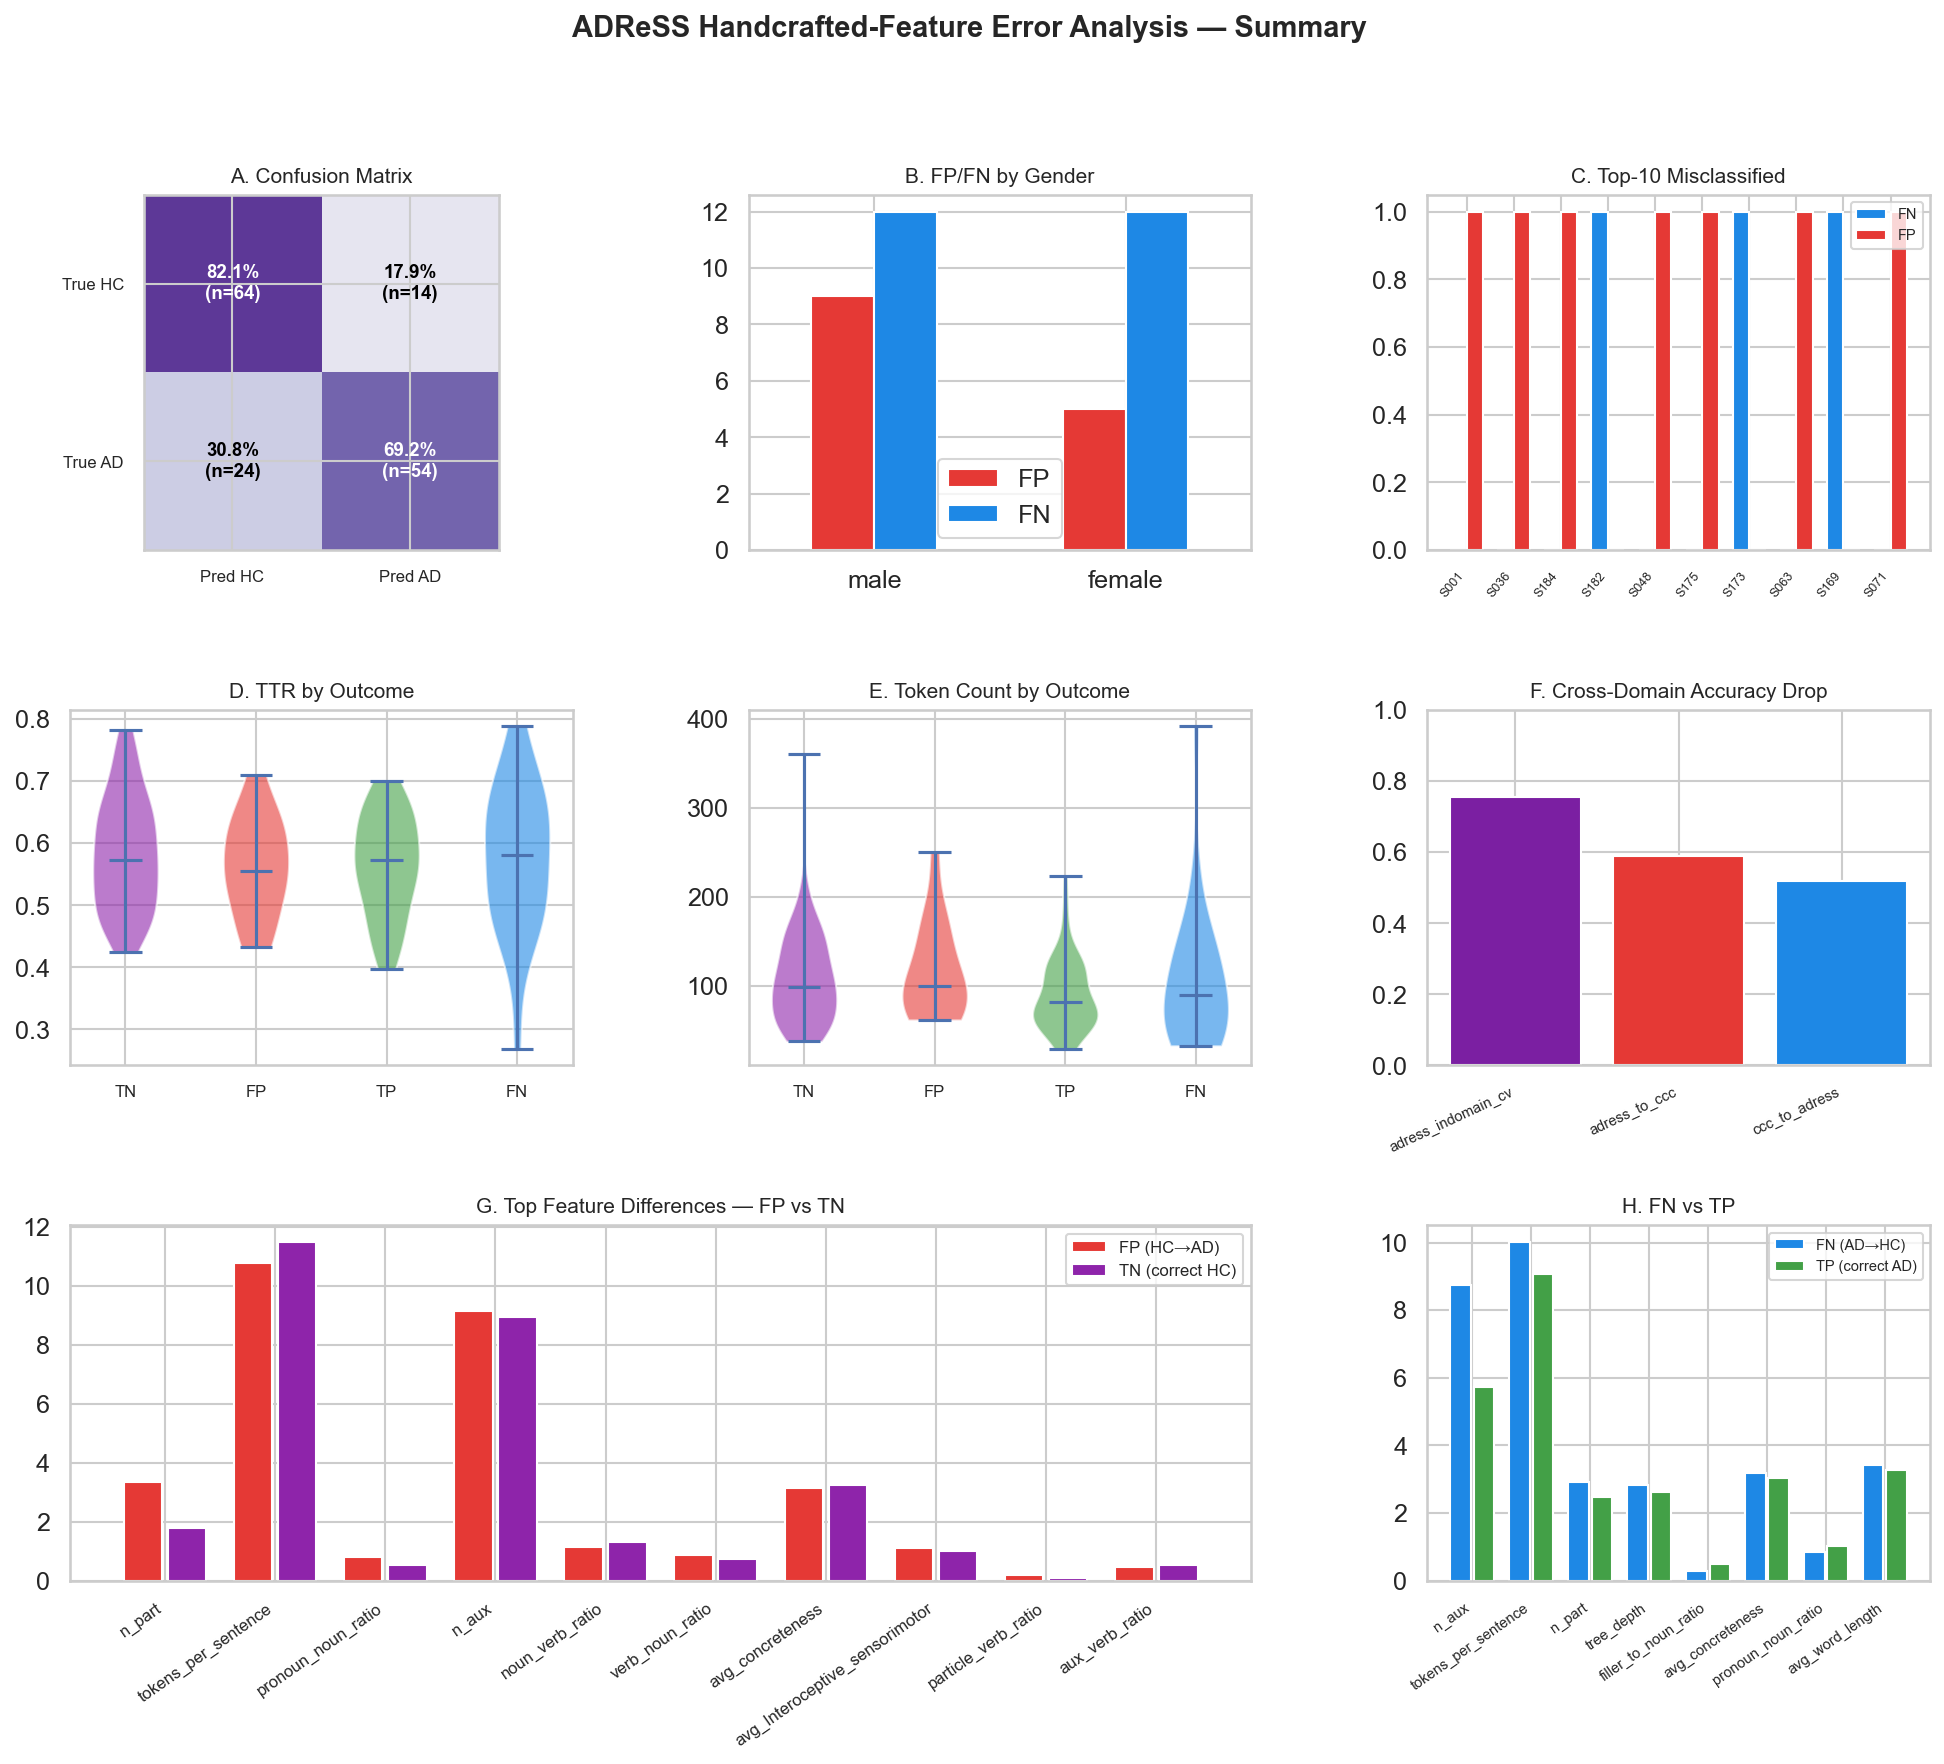


All outputs saved to: /Users/gloria/Documents/uniproject/thesis/outputs/error_analysis_results
All visualisations saved to: /Users/gloria/Documents/uniproject/thesis/visualizations/error_analysis_visualizations


In [20]:
# ── Consolidated summary figure ────────────────────────────────────────────
fig = plt.figure(figsize=(16, 12))
gs  = fig.add_gridspec(3, 3, hspace=0.45, wspace=0.35)

# Panel A: normalised confusion matrix
ax_cm = fig.add_subplot(gs[0, 0])
im = ax_cm.imshow(cm_norm, cmap='Purples', vmin=0, vmax=1)
for i in range(2):
    for j in range(2):
        col = 'white' if cm_norm[i,j] > 0.55 else 'black'
        ax_cm.text(j, i, f'{cm_norm[i,j]*100:.1f}%\n(n={cm_raw[i,j]})',
                   ha='center', va='center', fontsize=9, fontweight='bold', color=col)
ax_cm.set_xticks([0,1]); ax_cm.set_xticklabels(['Pred HC','Pred AD'], fontsize=8)
ax_cm.set_yticks([0,1]); ax_cm.set_yticklabels(['True HC','True AD'], fontsize=8)
ax_cm.set_title('A. Confusion Matrix', fontsize=10)

# Panel B: FP/FN by gender
ax_gen = fig.add_subplot(gs[0, 1])
gdf2 = gender_df.set_index('gender')[['FP','FN']]
gdf2.plot(kind='bar', ax=ax_gen, color=[PALETTE['FP'], PALETTE['FN']], rot=0, edgecolor='white')
ax_gen.set_title('B. FP/FN by Gender', fontsize=10)
ax_gen.set_xlabel('')

# Panel C: top-10 misclassified
ax_top = fig.add_subplot(gs[0, 2])
top10 = misclass_summary[misclass_summary.total_errors>0].head(10)
x10 = np.arange(len(top10))
w10 = 0.35
ax_top.bar(x10-w10/2, top10['n_fn'], w10, label='FN', color=PALETTE['FN'])
ax_top.bar(x10+w10/2, top10['n_fp'], w10, label='FP', color=PALETTE['FP'])
ax_top.set_xticks(x10)
ax_top.set_xticklabels(top10['participant_id'], rotation=50, ha='right', fontsize=6)
ax_top.set_title('C. Top-10 Misclassified', fontsize=10)
ax_top.legend(fontsize=7)

# Panel D: TTR violin
ax_ttr = fig.add_subplot(gs[1, 0])
plot_data_ttr = [subj_len.loc[subj_len.outcome_label==o, 'ttr'].dropna().values for o in order]
vp = ax_ttr.violinplot(plot_data_ttr, positions=range(4), showmedians=True)
for body, c in zip(vp['bodies'], colors):
    body.set_facecolor(c); body.set_alpha(0.6)
ax_ttr.set_xticks(range(4)); ax_ttr.set_xticklabels(order, fontsize=8)
ax_ttr.set_title('D. TTR by Outcome', fontsize=10)

# Panel E: token count violin
ax_tok = fig.add_subplot(gs[1, 1])
plot_data_tok = [subj_len.loc[subj_len.outcome_label==o, 'approx_token_count'].dropna().values for o in order]
vp2 = ax_tok.violinplot(plot_data_tok, positions=range(4), showmedians=True)
for body, c in zip(vp2['bodies'], colors):
    body.set_facecolor(c); body.set_alpha(0.6)
ax_tok.set_xticks(range(4)); ax_tok.set_xticklabels(order, fontsize=8)
ax_tok.set_title('E. Token Count by Outcome', fontsize=10)

# Panel F: cross-domain accuracy
ax_cross = fig.add_subplot(gs[1, 2])
cross_acc = compare[['experiment', 'accuracy']]
bar_cols   = ['#7B1FA2' if 'indomain' in e else
               '#E53935' if 'adress_to_ccc' in e else '#1E88E5'
               for e in cross_acc['experiment']]
ax_cross.bar(range(len(cross_acc)), cross_acc['accuracy'], color=bar_cols, edgecolor='white')
ax_cross.set_xticks(range(len(cross_acc)))
ax_cross.set_xticklabels(cross_acc['experiment'], rotation=25, ha='right', fontsize=7)
ax_cross.set_ylim(0, 1)
ax_cross.set_title('F. Cross-Domain Accuracy Drop', fontsize=10)

# Panel G-I: FP vs TN top feature differences
ax_feat_fp = fig.add_subplot(gs[2, :2])
fp_diff = (pattern_df[pattern_df.comparison=='FP_vs_TN']
           .sort_values('abs_diff', ascending=False).head(10)
           .set_index('feature'))
x_f = np.arange(len(fp_diff))
ax_feat_fp.bar(x_f-0.2, fp_diff['mean_FP'], 0.35, label='FP (HC→AD)', color=PALETTE['FP'])
ax_feat_fp.bar(x_f+0.2, fp_diff['mean_TN'], 0.35, label='TN (correct HC)', color=PALETTE['TN'])
ax_feat_fp.set_xticks(x_f)
ax_feat_fp.set_xticklabels(fp_diff.index, rotation=35, ha='right', fontsize=8)
ax_feat_fp.set_title('G. Top Feature Differences — FP vs TN', fontsize=10)
ax_feat_fp.legend(fontsize=8)

ax_feat_fn = fig.add_subplot(gs[2, 2])
fn_diff = (pattern_df[pattern_df.comparison=='FN_vs_TP']
           .sort_values('abs_diff', ascending=False).head(8)
           .set_index('feature'))
x_n = np.arange(len(fn_diff))
ax_feat_fn.bar(x_n-0.2, fn_diff['mean_FN'], 0.35, label='FN (AD→HC)', color=PALETTE['FN'])
ax_feat_fn.bar(x_n+0.2, fn_diff['mean_TP'], 0.35, label='TP (correct AD)', color=PALETTE['TP'])
ax_feat_fn.set_xticks(x_n)
ax_feat_fn.set_xticklabels(fn_diff.index, rotation=35, ha='right', fontsize=7)
ax_feat_fn.set_title('H. FN vs TP', fontsize=10)
ax_feat_fn.legend(fontsize=7)

fig.suptitle('ADReSS Handcrafted-Feature Error Analysis — Summary', fontsize=14, fontweight='bold')
plt.savefig(os.path.join(VIZ_DIR, 'error_analysis_summary_figure.png'), dpi=200)
plt.show()
print(f'\nAll outputs saved to: {OUTPUT_DIR}')
print(f'All visualisations saved to: {VIZ_DIR}')